In [ ]:
import pandas as pd
import re
import emoji
import numpy as np
import swifter
import nltk
d=pd.read_csv("raw_tweets_text.csv",nrows=1500000)
emoji_df=pd.read_csv("Emoji_Sentiment_Data_v1.0.csv")
d=d.drop_duplicates(subset="text")
d.sample(10)

C:\Users\gfili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,text
1199908,783345868892147712,G3 C1&amp;C2 Writing our own rubrics. #cwcatho...
363577,768547441629069312,"“When the student is ready, the teacher will a..."
951196,781443043186581504,#Vivendi is on Web9 - https://t.co/dUAuVZnHYl ...
1408948,784813489395294208,Feeling gud before the comedy presentation htt...
933625,781295978322157568,GUESS WHO FINALLY BOUGHT THEIR COMPUTER https:...
563575,769149357786476544,"RT @GabrielleKent: America, here we come! #Alf..."
1098997,782458672916168704,#news Destroy everything in the Goat Turbo Att...
191919,768125020682027012,"RT @GabbysQuilts: CLEARANCE, Sewing Travel Cas..."
609645,769231138350956544,Actual good pic of me https://t.co/G4eF35iPx2
603621,769220631594315776,FDA recommends testing for Zika in all donated...


In [16]:
#Clean text
def clean_tweet(text):
    if not isinstance(text,str):
        return ""
    text=text.lower() #lower text
    text=re.sub(r"https?://\S+|www\.\S+","",text) #remove URLs
    text=re.sub(r"@\w+","",text) #remove mention
    text=re.sub(r"\brt\b","",text) #remove retweet
    text=re.sub(r"#(\w+)",r"\1",text) # remove hashtag
    text=re.sub(r"[\n\t]","",text) # remove newline and tab
    text=re.sub(r"[^\w\s]"," ",text)
    return text.strip()

#Transform emoji in token
def demojize_text(text):
    text=emoji.demojize(text,language='en')
    text=re.sub(r":([a-z_]+):",r" emoji_\1",text)
    return text.strip()


d["demojize"]=d["text"].swifter.apply(demojize_text)
d["text_clean"]=d["text"].swifter.apply(clean_tweet)

d=d[d["text_clean"].str.split().str.len()>=4]
d=d.drop_duplicates(subset="text_clean")

d.sample(10)

Pandas Apply: 100%|██████████| 1037807/1037807 [00:09<00:00, 113275.07it/s]


,id,text,demojize,text_clean,final_tokens
1353461,784416804735029250,New Perk - @venicetheseries long sleeve black ...,New Perk - @venicetheseries long sleeve black ...,new perk long sleeve black t shirt get per...,"[new, perk, USER, long, sleeve, black, shirt, ..."
927388,781252688877064192,I've just watched episode S01E04 of Freaks a...,I've just watched episode S01E04 of Freaks a...,i ve just watched episode s01e04 of freaks a...,"[watch, episode, s01e04, freak, geek, freaksan..."
1304189,784073874224902145,PijushDu : Why are payday loan ads still showi...,PijushDu : Why are payday loan ads still showi...,pijushdu why are payday loan ads still showi...,"[pijushdu, payday, loan, ad, still, show, goog..."
50998,758078463047667713,RT @entertainall4: Three bear cubs in top of t...,RT @entertainall4: Three bear cubs in top of t...,three bear cubs in top of the tree,"[USER, three, bear, cub, top, tree]"
1270819,783823621080788992,Portrait of Maggie Woodard. https://t.co/2HdEk...,Portrait of Maggie Woodard. https://t.co/2HdEk...,portrait of maggie woodard,"[portrait, maggie, woodard]"
1110954,782569599699185664,How #deeplearning allowed computers to see htt...,How #deeplearning allowed computers to see htt...,how deeplearning allowed computers to see,"[deeplearning, allow, computer, see]"
1346844,784380033251049472,A rare sighting: Smiling coach. Seriously that...,A rare sighting: Smiling coach. Seriously that...,a rare sighting smiling coach seriously that...,"[rare, sight, smile, coach, seriously, smile, ..."
11989,758030144636194816,RT @_Carja: It's way past time to stop the GOP...,RT @_Carja: It's way past time to stop the GOP...,it s way past time to stop the gop votegopoutv...,"[USER, way, past, time, stop, gop, votegopoutv..."
1463883,785228603869003776,Autumn is in the air and all around! 🎃 What a...,Autumn is in the air and all around! :jack-o-l...,autumn is in the air and all around what a...,"[autumn, air, around, favorite, fall, family, ..."
111657,758162063890014212,RT @youngjaeforthai: Morning #youngjae #got7で妄...,RT @youngjaeforthai: Morning #youngjae #got7で妄...,morning youngjae got7で妄想 got7,"[USER, morning, youngjae, get, 7で妄想, get, 7]"


In [17]:
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords,wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

#Setup NLTK
tokenizer=TweetTokenizer()
stopwords_set=set(stopwords.words('english'))-{'not','no','never','neither','nor'}
lemmatizer=WordNetLemmatizer()

#Function to convert NLTK POS tags to WordNet POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'): 
        return wordnet.NOUN
    elif tag.startswith('R'): 
        return wordnet.ADV
    else:
        return wordnet.NOUN #Default

def lemmatize_tokens(tokens):
    tagged_tokens=pos_tag(tokens)
    final=[]
    for word, tag in tagged_tokens:
        if(word.isalpha() and word.lower()) not in stopwords_set:
            final.append(lemmatizer.lemmatize(word,get_wordnet_pos(tag)))
    return final

def tokenize_lemmatize(text):
    tokens=tokenizer.tokenize(text)
    return lemmatize_tokens(tokens)
d["final_tokens"]=d["text_clean"].swifter.apply(tokenize_lemmatize)



Pandas Apply: 100%|██████████| 1004739/1004739 [05:34<00:00, 3007.28it/s]


In [28]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB,MultinomialNB
from sklearn.metrics import classification_report,accuracy_score
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

sia=SentimentIntensityAnalyzer()

def vader_label(score):
    if score>=0.05:
        return "Positive"
    elif score<=-0.05:
        return "Negative"
    else:
        return "Neutral"
    
df_with_emoji=d.copy()
df_with_emoji["emoji_score"]=df_with_emoji["text_clean"].swifter.apply(lambda x: sia.polarity_scores(str(x))['compound'])
df_with_emoji["sentiment"]=df_with_emoji["emoji_score"].swifter.apply(vader_label)

df_filtered=df_with_emoji[df_with_emoji["sentiment"] !="Neutral"].copy()

#Features & Target
X_test=df_filtered["final_tokens"].apply(lambda t: " ".join(t)) #Tokenized text
X_extra=df_filtered["emoji_score"].values.reshape(-1,1)
y=df_filtered["sentiment"]

#Train/test split
X_train_text, X_test_text, X_train_extra,X_test_extra,y_train,y_test=train_test_split(X_test,X_extra,y,test_size=0.2,random_state=42,stratify=y)

#TF-IDF
tfidf=TfidfVectorizer(ngram_range=(1,4),min_df=3,max_df=0.8,sublinear_tf=True)
X_train_tfidf=tfidf.fit_transform(X_train_text)
X_test_tfidf=tfidf.transform(X_test_text)

#Scaling emoji_score
scaler=MinMaxScaler()
X_train_extra_scaled=scaler.fit_transform(X_train_extra+1)/2
X_test_extra_scaled=scaler.transform(X_test_extra+1)/2

X_train_final=hstack([X_train_tfidf,X_train_extra_scaled])
X_test_final=hstack([X_test_tfidf,X_test_extra_scaled])

model=MultinomialNB(alpha=1)
model.fit(X_train_final,y_train)
y_predMultinomial=model.predict(X_test_final)

print(f"Global Accuracy with MultinomialNB: {accuracy_score(y_test,y_predMultinomial):.2f}\n")
print(classification_report(y_test,y_predMultinomial))


Pandas Apply: 100%|██████████| 1004739/1004739 [00:00<00:00, 2569564.47it/s]


Global Accuracy with MultinomialNB: 0.87

              precision    recall  f1-score   support

    Negative       0.93      0.55      0.69     30917
    Positive       0.86      0.99      0.92     88038

    accuracy                           0.87    118955
   macro avg       0.90      0.77      0.81    118955
weighted avg       0.88      0.87      0.86    118955



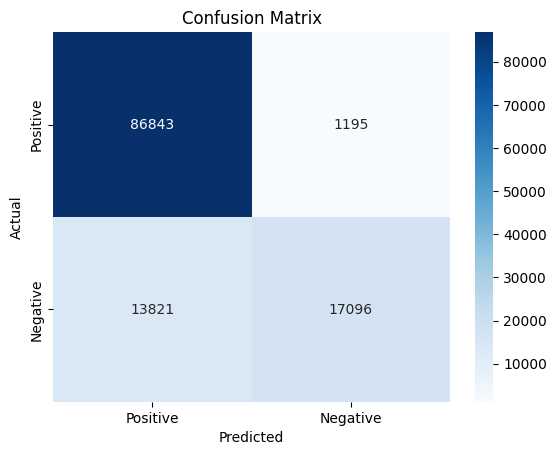

In [29]:
#Create a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,y_predMultinomial,labels=["Positive","Negative"])
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Negative"],yticklabels=["Positive","Negative"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Global Accuracy with ComplementNB: 0.92

              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85     30917
    Positive       0.95      0.94      0.95     88038

    accuracy                           0.92    118955
   macro avg       0.89      0.90      0.90    118955
weighted avg       0.92      0.92      0.92    118955



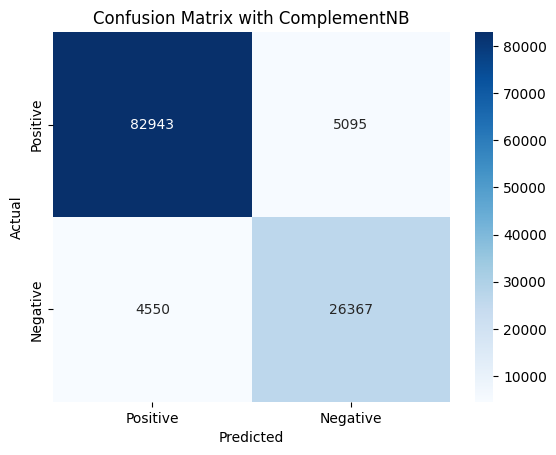

In [30]:
model2=ComplementNB(alpha=1) #Using Laplace smoothing
model2.fit(X_train_final,y_train)
y_predComplement=model2.predict(X_test_final)
print(f"Global Accuracy with ComplementNB: {accuracy_score(y_test,y_predComplement):.2f}\n")
print(classification_report(y_test,y_predComplement))

cmw=confusion_matrix(y_test,y_predComplement,labels=["Positive","Negative"])
sns.heatmap(cmw,annot=True,fmt="d",cmap="Blues",xticklabels=["Positive","Negative"],yticklabels=["Positive","Negative"])
plt.title("Confusion Matrix with ComplementNB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()